# Data Preprocessing & Visualization

### Nama: Oktova Y. P. Samosir
### NIM : 42324001

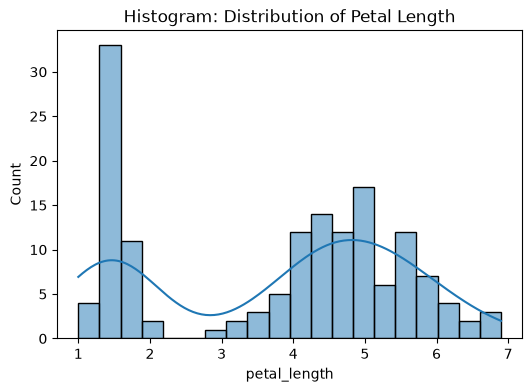

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
# Load dataset
df = sns.load_dataset("iris")
# 1. Histogram → Distribusi
plt.figure(figsize=(6,4))
sns.histplot(df['petal_length'], bins=20, kde=True)
plt.title("Histogram: Distribution of Petal Length")
plt.show()


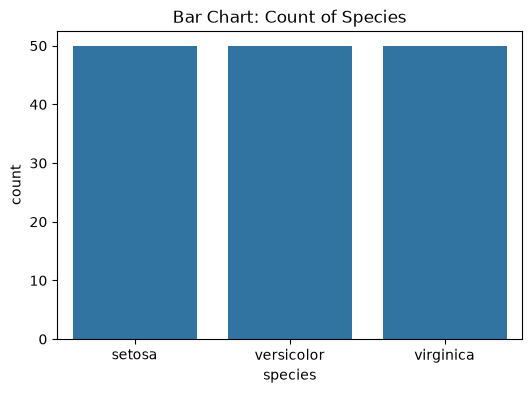

In [4]:
# 2. Bar Chart → Count per category
plt.figure(figsize=(6,4))
sns.countplot(x="species", data=df)
plt.title("Bar Chart: Count of Species")
plt.show()

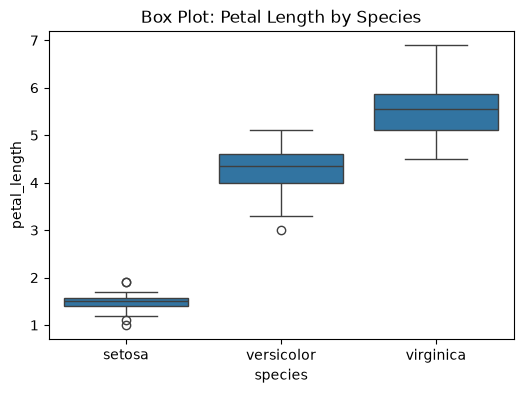

In [5]:
# 3. Box Plot → Spread + Outlier detection
plt.figure(figsize=(6,4))
sns.boxplot(x="species", y="petal_length", data=df)
plt.title("Box Plot: Petal Length by Species")
plt.show()


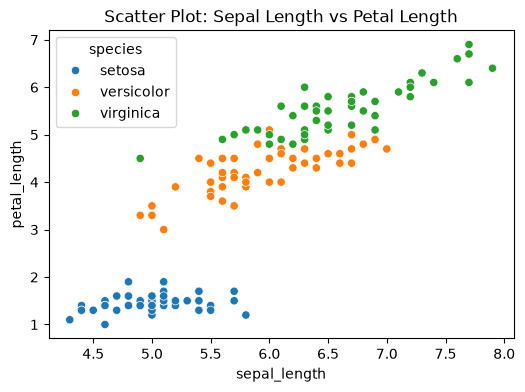

In [7]:
# 4. Scatter Plot → Relationship
plt.figure(figsize=(6,4))
sns.scatterplot(x="sepal_length", y="petal_length", hue="species", data=df)
plt.title("Scatter Plot: Sepal Length vs Petal Length")
plt.show()


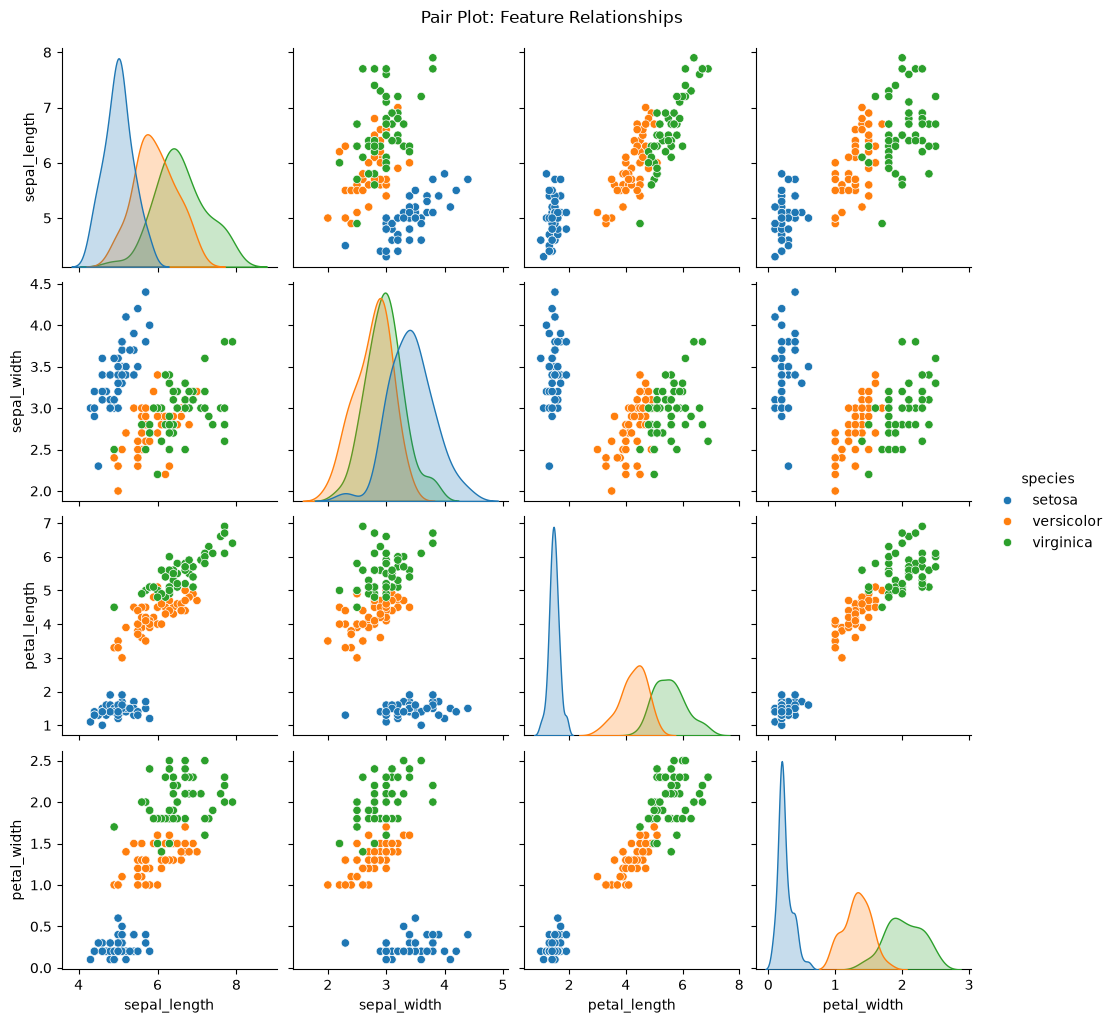

In [8]:
# 5. Pair Plot → Multivariate relationship
sns.pairplot(df, hue="species")
plt.suptitle("Pair Plot: Feature Relationships", y=1.02)
plt.show()


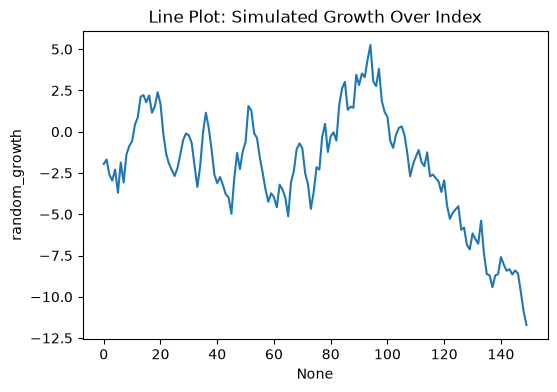

In [9]:
# 6. Line Plot → Example time series (simulate cumulative sum)
plt.figure(figsize=(6,4))
df["random_growth"] = np.random.randn(len(df)).cumsum()
sns.lineplot(x=df.index, y="random_growth", data=df)
plt.title("Line Plot: Simulated Growth Over Index")
plt.show()


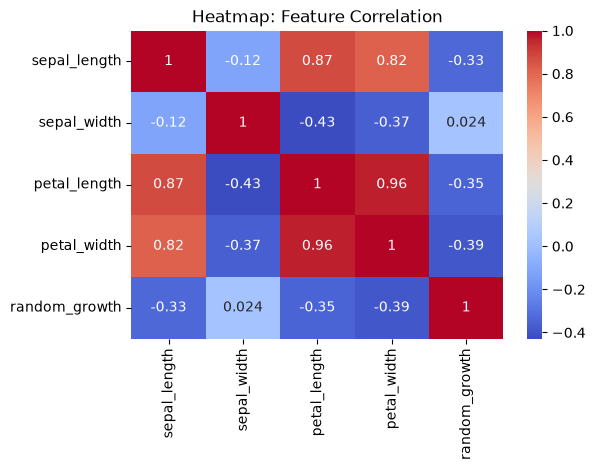

In [10]:
# 7. Heatmap → Correlation matrix
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap: Feature Correlation")
plt.show()


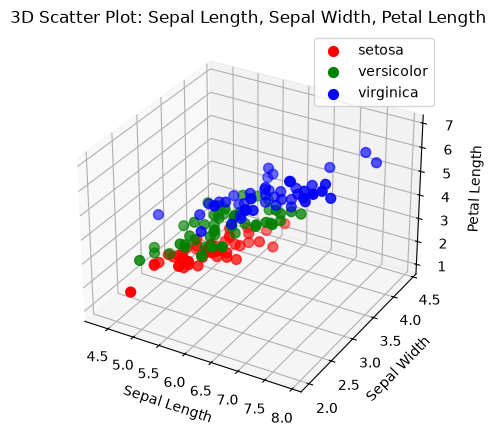

In [11]:
# 8. 3D Scatter Plot → 3 features visualization
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")
species = df["species"].unique()
colors = ["r", "g", "b"]
for sp, col in zip(species, colors):
 subset = df[df["species"] == sp]
 ax.scatter(subset["sepal_length"], subset["sepal_width"], subset["petal_length"],
 c=col, label=sp, s=50)
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")
ax.set_title("3D Scatter Plot: Sepal Length, Sepal Width, Petal Length")
ax.legend()
plt.show()

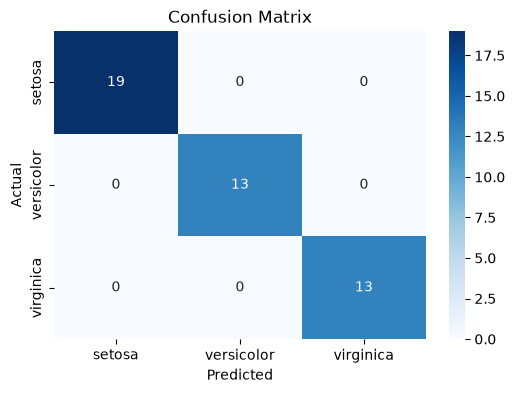

In [16]:
# 9. Model-Specific Visualization (e.g Modeling using RandomForest)
# Split data
X = df.drop("species", axis=1)
y = df["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# 9.1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model .classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

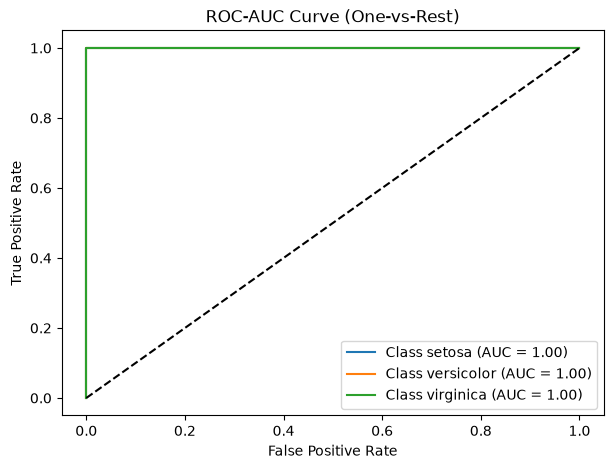

In [18]:
# 9.2. ROC-AUC Curve (multi-class with One-vs-Rest)
# Binarize labels
y_bin = label_binarize(y, classes=model.classes_)
n_classes = y_bin.shape[1]

# Train OvR classifier
ovr_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ovr_model.fit(X_train, label_binarize(y_train, classes=model.classes_))

y_score = ovr_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=model.classes_)

# Plot ROC curve
plt.figure(figsize=(7, 5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve (One-vs-Rest)")
plt.legend()
plt.show()

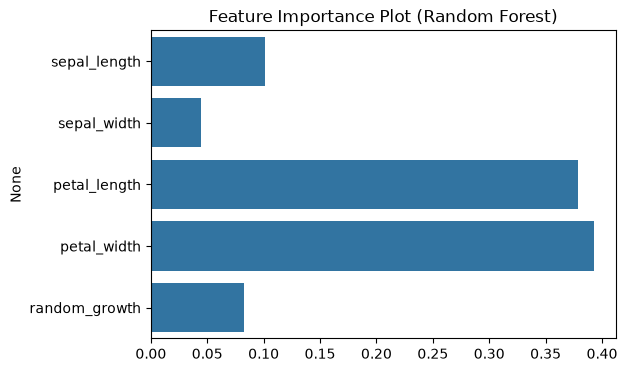

In [19]:
# 9.3. Feature Importance Plot → Random Forest
X = df.drop("species", axis=1)
y = df["species"]
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance Plot (Random Forest)")
plt.show()


In [13]:
%pip install --upgrade seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install pandas matplotlib seaborn scikit-learn numpy

  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
   -----------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
